<a href="https://colab.research.google.com/github/d1jeett/dap-2024/blob/main/les06/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа №6. Линейная регрессия

Выполните следующие задания:

1. Откройте в файл в Google Colab (используйте собственный форк репозитория).
2. Решите задачи.
3. Сохраните результат в ваш репозиторий github в директорию ./les06
4. Создайте pull request в репозиторий https://github.com/chebotarevsa/dap-2024. Название pull request должно иметь формат "<Номер лабораторной работы>  <Номер группы> <ФИО>"
5. Сдайте работу в системе "Пегас", в отчет укажите ссылку на pull request

Набор данных Diabetes (Диабет) содержит 442 образца с 10-ю признаками: возраст, пол, индекс массы тела, средний показатель давления крови и шесть измерений сыворотки крови. Целевое значение - количественный показатель прогрессирования заболевания через год после анализов.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Извлечение данных

In [2]:
from sklearn import datasets
diabetes = datasets.load_diabetes()

1. Выведете описание набора данных и наименование признаков.

In [5]:
from sklearn import datasets
diabetes = datasets.load_diabetes()
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


### Подготовка данных

2. Из загруженного набора данных создайте DataFrame, содержащий как признаки, так и целевое значение. Выведите первые 5 строк набора.

In [6]:
import pandas as pd
from sklearn import datasets
diabetes = datasets.load_diabetes()
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target
print("ервые 5 строк набора данных:\n")
print(data.head(5))

ервые 5 строк набора данных:

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


3. Выведете информацию о типах данных в наборе. Имеются ли в наборе категориальные признаки? Имеются ли в наборе данные имеющие значение null?

In [11]:
import seaborn as sns

df = sns.load_dataset('iris')

print("Типы данных:")
print(df.dtypes)

cat_cols = df.select_dtypes(include=['object', 'category']).columns
print(f"\nКатегориальные признаки ({len(cat_cols)}):", list(cat_cols))

null_count = df.isnull().sum().sum()
print(f"\nПропущенные значения (null): {null_count}")
if null_count > 0:
    print("Столбцы с null:")
    print(df.isnull().sum()[df.isnull().sum() > 0])

Типы данных:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object

Категориальные признаки (1): ['species']

Пропущенные значения (null): 0


## Исследование данных

4. Постройте матрицу корреляции.

In [13]:
import pandas as pd
from sklearn import datasets
diabetes = datasets.load_diabetes()
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target
correlation_matrix = data.corr()
print("Матрица корреляции:\n")
print(correlation_matrix)

Матрица корреляции:

             age       sex       bmi        bp        s1        s2        s3  \
age     1.000000  0.173737  0.185085  0.335428  0.260061  0.219243 -0.075181   
sex     0.173737  1.000000  0.088161  0.241010  0.035277  0.142637 -0.379090   
bmi     0.185085  0.088161  1.000000  0.395411  0.249777  0.261170 -0.366811   
bp      0.335428  0.241010  0.395411  1.000000  0.242464  0.185548 -0.178762   
s1      0.260061  0.035277  0.249777  0.242464  1.000000  0.896663  0.051519   
s2      0.219243  0.142637  0.261170  0.185548  0.896663  1.000000 -0.196455   
s3     -0.075181 -0.379090 -0.366811 -0.178762  0.051519 -0.196455  1.000000   
s4      0.203841  0.332115  0.413807  0.257650  0.542207  0.659817 -0.738493   
s5      0.270774  0.149916  0.446157  0.393480  0.515503  0.318357 -0.398577   
s6      0.301731  0.208133  0.388680  0.390430  0.325717  0.290600 -0.273697   
target  0.187889  0.043062  0.586450  0.441482  0.212022  0.174054 -0.394789   

              s4  

5. Постройте диаграмму рассеяния целевого значение и признака, коэффициент корреляции которого с  целевым значением, самый высокий.

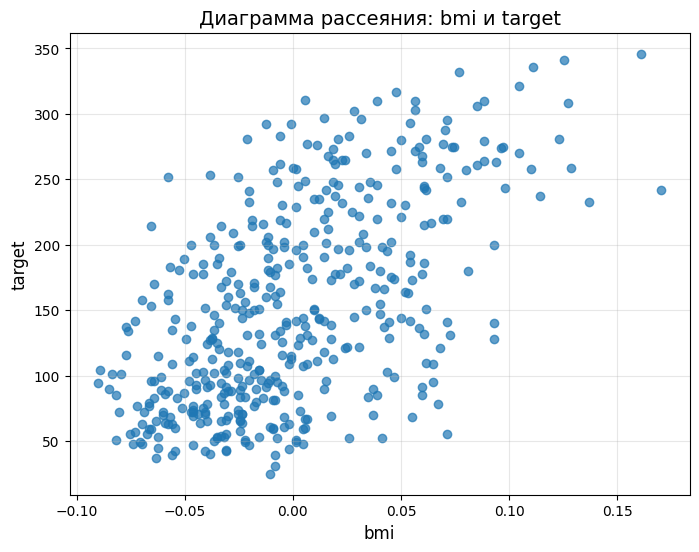

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
diabetes = datasets.load_diabetes()
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target
correlation_matrix = data.corr()
max_corr_feature = correlation_matrix['target'].drop('target').idxmax()
plt.figure(figsize=(8, 6))
plt.scatter(data[max_corr_feature], data['target'], alpha=0.7)
plt.title(f"Диаграмма рассеяния: {max_corr_feature} и target", fontsize=14)
plt.xlabel(max_corr_feature, fontsize=12)
plt.ylabel('target', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

6. Сформируйте набор признаков (X) из 5 признаков с самым высоким коэффициентом корреляции с целевым значением. Сформируйте набор для целевого значения (y).

In [16]:
import pandas as pd
from sklearn import datasets
diabetes = datasets.load_diabetes()
data = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target
correlation_matrix = data.corr()
top_features = correlation_matrix['target'].drop('target').abs().sort_values(ascending=False).head(5).index
X = data[top_features]
y = data['target']
print("5 признаков с наивысшей корреляцией с целевым значением:\n", top_features.tolist())
print("\nПример первых 5 строк X:\n", X.head())
print("\nПример первых 5 строк y:\n", y.head())

5 признаков с наивысшей корреляцией с целевым значением:
 ['bmi', 's5', 'bp', 's4', 's3']

Пример первых 5 строк X:
         bmi        s5        bp        s4        s3
0  0.061696  0.019907  0.021872 -0.002592 -0.043401
1 -0.051474 -0.068332 -0.026328 -0.039493  0.074412
2  0.044451  0.002861 -0.005670 -0.002592 -0.032356
3 -0.011595  0.022688 -0.036656  0.034309 -0.036038
4 -0.036385 -0.031988  0.021872 -0.002592  0.008142

Пример первых 5 строк y:
 0    151.0
1     75.0
2    141.0
3    206.0
4    135.0
Name: target, dtype: float64


## Предсказательная модель

7. Разделите набор данных на два, одни для обучения модели другой для проверки. Тестовый набор должен содержать 25 процентов данных.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("Размер обучающего набора (X_train, y_train):", X_train.shape, y_train.shape)
print("Размер тестового набора (X_test, y_test):", X_test.shape, y_test.shape)

Размер обучающего набора (X_train, y_train): (331, 5) (331,)
Размер тестового набора (X_test, y_test): (111, 5) (111,)


8. Выполните обучение модели.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

## Проверка модели

9. Расчитайте Root mean squared error (RMSE)

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
print(f"Среднеквадратичная ошибка (RMSE): {rmse}")

Среднеквадратичная ошибка (RMSE): 53.784557443405994


10. Расчитайте R² (коэффициент детерминации)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)
print(f"Среднеквадратичная ошибка (RMSE): {rmse}")
print(f"Коэффициент детерминации (R²): {r2}")

Среднеквадратичная ошибка (RMSE): 53.784557443405994
Коэффициент детерминации (R²): 0.4768642138880054


## Вопросы для защиты

1. Какие типы машинного обучения вы знаете?
Обучение с учителем, без учителя, с подкреплением, частичное, трансферное, самообучение.
2. Чем отличается обучение с учителем и без учителя?
Есть метки (Y). Без учителя: Нет меток, поиск паттернов.
3. Чем пакетное обучение отличается от динамического?
Вся обучающая выборка сразу. Динамическое/онлайн: Постепенно, по одному объекту.
4. Чем обучение на основе образцов отличается от обучения на основе модели?
Запоминает примеры (k-NN). На модели: Строит математическую модель (линейная регрессия).
5. Что такое линейная регрессия?
Линейная регрессия: Модель y = wX + b, предсказывает число.
6. Что такое градиентный спуск?
Градиентный спуск: Итеративная оптимизация параметров модели через градиент функции потерь.
7. Как правильно обрабатывать категориальные признаки?
Категориальные признаки: One-Hot Encoding, Label Encoding, Target Encoding, Embedding.
8. Что такое матрица корреляции?
Матрица корреляции: Таблица попарных корреляций между признаками (-1 до 1).
9. Что показывает метрика RMSE?
RMSE: Средняя ошибка предсказания в исходных единицах (корень из MSE).
10. Что показывает метрика R²?
R²: Доля дисперсии Y, объясненная моделью (0–1, чем ближе к 1, тем лучше).